Part 1 — Perceptron from Scratch

In [15]:
# ─────────────────────────────────────────────────────────
# BLOCK 1: Imports and load the dataset
# ─────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

np.random.seed(42)

# ── Load Iris dataset ──
# Iris has 3 flower types. We keep only 2 (binary classification)
# and 2 features (so we can draw a 2D decision boundary).
iris = load_iris()
X = iris.data[:, [2, 3]]   # feature 2 = petal length, feature 3 = petal width
y = iris.target

# Keep only classes 0 (Setosa) and 1 (Versicolor)
mask = y < 2
X, y = X[mask], y[mask]

print("Data shape:", X.shape)
print("Classes:", np.unique(y), "(0=Setosa, 1=Versicolor)")

# ── Train/test split (80/20) ──
idx = np.random.permutation(len(X))
n_train = int(0.8 * len(X))
X_train, y_train = X[idx[:n_train]], y[idx[:n_train]]
X_test,  y_test  = X[idx[n_train:]], y[idx[n_train:]]

# ── Standardize features (mean=0, std=1) ──
mu, sd = X_train.mean(0), X_train.std(0)
X_train = (X_train - mu) / sd
X_test  = (X_test  - mu) / sd

print("Training samples:", len(X_train))
print("Testing  samples:", len(X_test))

Data shape: (100, 2)
Classes: [0 1] (0=Setosa, 1=Versicolor)
Training samples: 80
Testing  samples: 20


Converged at epoch 2 (0 errors)

Final weights: w = [0.1621 0.1505]
Final bias:    b = 0.1000
Final training loss (misclassifications): 0


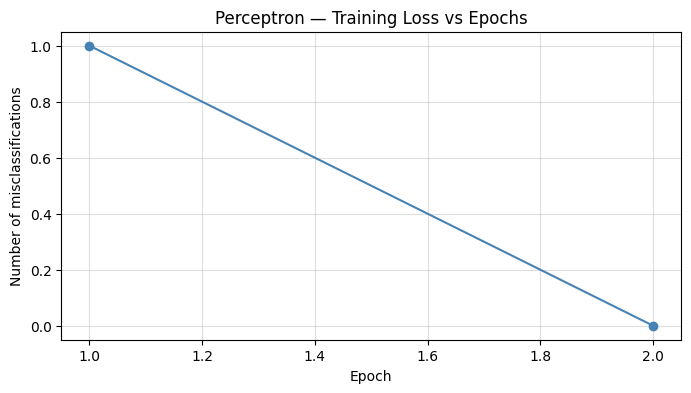

In [16]:
# ─────────────────────────────────────────────────────────
# BLOCK 2: Implement and train the Perceptron
# ─────────────────────────────────────────────────────────

def train_perceptron(X, y, learning_rate=0.1, epochs=50):
    """
    The Perceptron algorithm.

    Prediction: ŷ = sign(w·x + b)   →  +1 or -1

    Learning rule (only updates when WRONG):
      if prediction is wrong:
          w = w + lr · y · x
          b = b + lr · y

    The 'loss' we track = number of misclassified points per epoch.
    When this reaches 0, the data is perfectly separated.
    """
    w = np.zeros(X.shape[1])    # start weights at 0
    b = 0.0                     # start bias at 0

    # Perceptron needs labels as -1 and +1 (not 0 and 1)
    y_pm = np.where(y == 0, -1, 1)

    loss_history = []   # number of errors each epoch

    for epoch in range(epochs):
        errors = 0
        for i in range(len(X)):
            # Make a prediction: sign of (w·x + b)
            activation = X[i] @ w + b
            prediction = 1 if activation > 0 else -1

            # If wrong, update weights toward the correct answer
            if prediction != y_pm[i]:
                w = w + learning_rate * y_pm[i] * X[i]
                b = b + learning_rate * y_pm[i]
                errors += 1

        loss_history.append(errors)

        # Early stop if no errors (perfectly separated)
        if errors == 0:
            print(f"Converged at epoch {epoch+1} (0 errors)")
            break

    return w, b, loss_history

# Train
w_perc, b_perc, perc_loss = train_perceptron(X_train, y_train)

print(f"\nFinal weights: w = {w_perc.round(4)}")
print(f"Final bias:    b = {b_perc:.4f}")
print(f"Final training loss (misclassifications): {perc_loss[-1]}")

# ── Plot training loss (errors) vs epochs ──
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(perc_loss)+1), perc_loss, 'o-', color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('Number of misclassifications')
plt.title('Perceptron — Training Loss vs Epochs')
plt.grid(True, alpha=0.4)
plt.show()

CONFUSION MATRIX VALUES:
  True Positives  (TP) = 12
  True Negatives  (TN) = 8
  False Positives (FP) = 0
  False Negatives (FN) = 0
  Accuracy = 1.000


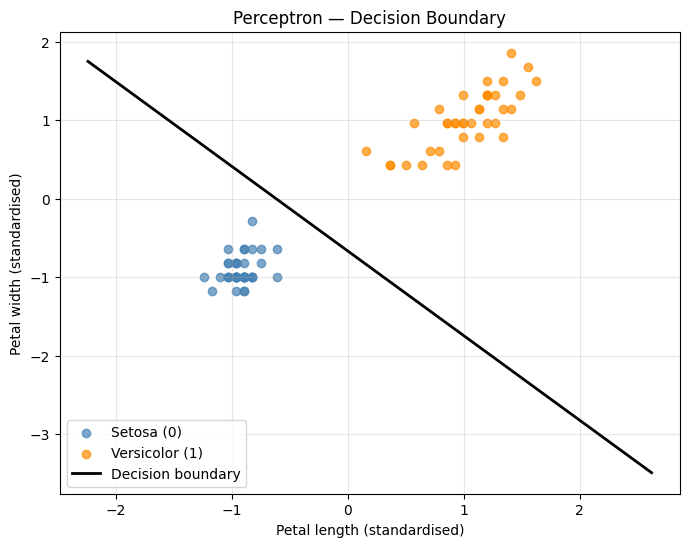

In [17]:
# ─────────────────────────────────────────────────────────
# BLOCK 3: Confusion matrix + decision boundary
# ─────────────────────────────────────────────────────────

# ── Predict on test set ──
test_activation = X_test @ w_perc + b_perc
y_pred = np.where(test_activation > 0, 1, 0)   # convert back to 0/1

# ── Confusion matrix values (computed manually) ──
TP = np.sum((y_pred == 1) & (y_test == 1))   # True Positives
TN = np.sum((y_pred == 0) & (y_test == 0))   # True Negatives
FP = np.sum((y_pred == 1) & (y_test == 0))   # False Positives
FN = np.sum((y_pred == 0) & (y_test == 1))   # False Negatives

print("CONFUSION MATRIX VALUES:")
print(f"  True Positives  (TP) = {TP}")
print(f"  True Negatives  (TN) = {TN}")
print(f"  False Positives (FP) = {FP}")
print(f"  False Negatives (FN) = {FN}")
print(f"  Accuracy = {(TP+TN)/len(y_test):.3f}")

# ── Decision boundary plot ──
plt.figure(figsize=(8, 6))

# Plot the two classes
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
            color='steelblue', label='Setosa (0)', alpha=0.7)
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
            color='darkorange', label='Versicolor (1)', alpha=0.7)

# The decision boundary is the line: w0·x0 + w1·x1 + b = 0
# Solving for x1:  x1 = -(w0·x0 + b) / w1
x0_vals = np.linspace(X_train[:,0].min()-1, X_train[:,0].max()+1, 100)
x1_vals = -(w_perc[0]*x0_vals + b_perc) / w_perc[1]
plt.plot(x0_vals, x1_vals, 'k-', linewidth=2, label='Decision boundary')

plt.xlabel('Petal length (standardised)')
plt.ylabel('Petal width (standardised)')
plt.title('Perceptron — Decision Boundary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Part 2 — Logistic Regression from Scratch

In [18]:
"""The key difference from the perceptron: instead of a hard sign() step,
logistic regression uses the smooth sigmoid function to output a probability
between 0 and 1. This gives a differentiable loss (log loss),
which lets us use gradient descent and track loss properly."""

'The key difference from the perceptron: instead of a hard sign() step, \nlogistic regression uses the smooth sigmoid function to output a probability \nbetween 0 and 1. This gives a differentiable loss (log loss), \nwhich lets us use gradient descent and track loss properly.'

Final weights: [2.4453 2.3822]
Final bias:    0.0540
Final training loss: 0.0189
Final test loss:     0.0154


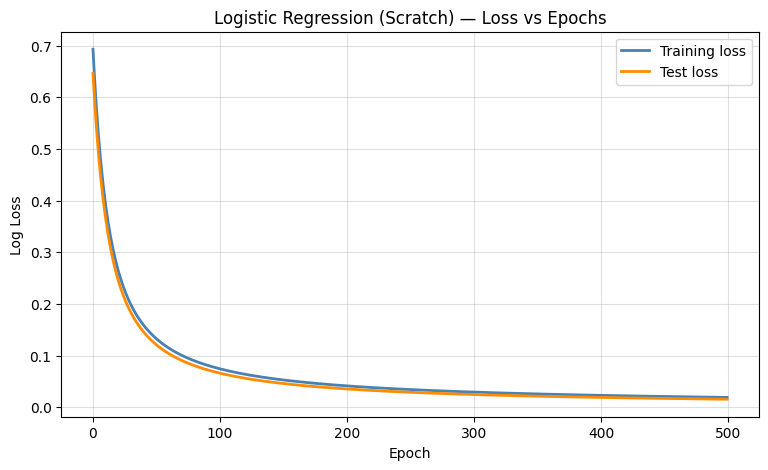

In [19]:
# ─────────────────────────────────────────────────────────
# BLOCK 4: Logistic Regression from scratch
# ─────────────────────────────────────────────────────────

def sigmoid(z):
    """Squashes any number into a probability between 0 and 1.
       sigmoid(z) = 1 / (1 + e^(-z))"""
    return 1 / (1 + np.exp(-z))

def log_loss(y_true, y_prob):
    """
    Binary Cross-Entropy (Log Loss).
    Loss = -mean( y·log(p) + (1-y)·log(1-p) )
    Punishes confident wrong predictions heavily.
    """
    y_prob = np.clip(y_prob, 1e-7, 1 - 1e-7)   # avoid log(0)
    return -np.mean(y_true*np.log(y_prob) + (1-y_true)*np.log(1-y_prob))

def train_logistic(X_tr, y_tr, X_te, y_te, learning_rate=0.1, epochs=500):
    """
    Logistic Regression via gradient descent.

    Each epoch:
      1. Predict probabilities: p = sigmoid(X·w + b)
      2. Compute gradients:
           dw = (1/m)·X^T·(p - y)
           db = (1/m)·Σ(p - y)
      3. Update: w -= lr·dw,  b -= lr·db
    """
    w = np.zeros(X_tr.shape[1])
    b = 0.0
    m = len(y_tr)

    train_losses, test_losses = [], []

    for epoch in range(epochs):
        # Predictions (probabilities)
        p = sigmoid(X_tr @ w + b)

        # Gradients
        dw = (1/m) * (X_tr.T @ (p - y_tr))
        db = (1/m) * np.sum(p - y_tr)

        # Update parameters
        w -= learning_rate * dw
        b -= learning_rate * db

        # Record train and test loss
        train_losses.append(log_loss(y_tr, p))
        test_losses.append(log_loss(y_te, sigmoid(X_te @ w + b)))

    return w, b, train_losses, test_losses

# Train
w_lr, b_lr, tr_loss, te_loss = train_logistic(X_train, y_train, X_test, y_test)

print(f"Final weights: {w_lr.round(4)}")
print(f"Final bias:    {b_lr:.4f}")
print(f"Final training loss: {tr_loss[-1]:.4f}")
print(f"Final test loss:     {te_loss[-1]:.4f}")

# ── Plot training loss AND test loss vs epochs ──
plt.figure(figsize=(9, 5))
plt.plot(tr_loss, color='steelblue', linewidth=2, label='Training loss')
plt.plot(te_loss, color='darkorange', linewidth=2, label='Test loss')
plt.xlabel('Epoch'); plt.ylabel('Log Loss')
plt.title('Logistic Regression (Scratch) — Loss vs Epochs')
plt.legend(); plt.grid(True, alpha=0.4)
plt.show()

Part 3 — Logistic Regression with scikit-learn

In [20]:
"""This shows how the same task takes 3 lines with a library.
scikit-learn's LogisticRegression doesn't expose per-epoch losses
(it uses a fast solver, not plain gradient descent),
so we compute the final train/test loss and visualise it
as a simple comparison."""

"This shows how the same task takes 3 lines with a library. \nscikit-learn's LogisticRegression doesn't expose per-epoch losses \n(it uses a fast solver, not plain gradient descent), \nso we compute the final train/test loss and visualise it \nas a simple comparison."

Learned weights: [[2.009 1.942]]
Learned bias:    [0.0809]
Training loss: 0.0345
Test loss:     0.0293
Test accuracy: 1.0000

CONFUSION MATRIX VALUES:
  TP = 12,  TN = 8,  FP = 0,  FN = 0


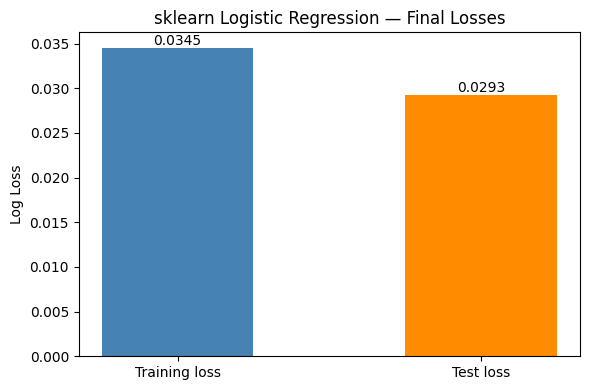

In [21]:
# ─────────────────────────────────────────────────────────
# BLOCK 5: Logistic Regression using scikit-learn
# ─────────────────────────────────────────────────────────

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss as sk_log_loss, confusion_matrix

# ── Train the model (just 2 lines!) ──
clf = LogisticRegression()
clf.fit(X_train, y_train)

# ── Predict ──
y_pred_sk = clf.predict(X_test)

# ── Compute losses ──
# predict_proba gives probability of each class; [:,1] = prob of class 1
train_loss_sk = sk_log_loss(y_train, clf.predict_proba(X_train))
test_loss_sk  = sk_log_loss(y_test,  clf.predict_proba(X_test))

print(f"Learned weights: {clf.coef_.round(4)}")
print(f"Learned bias:    {clf.intercept_.round(4)}")
print(f"Training loss: {train_loss_sk:.4f}")
print(f"Test loss:     {test_loss_sk:.4f}")
print(f"Test accuracy: {clf.score(X_test, y_test):.4f}")

# ── Confusion matrix values ──
cm = confusion_matrix(y_test, y_pred_sk)
TN, FP, FN, TP = cm.ravel()   # unpacks the 2x2 matrix
print(f"\nCONFUSION MATRIX VALUES:")
print(f"  TP = {TP},  TN = {TN},  FP = {FP},  FN = {FN}")

# ── Simple bar chart of train vs test loss ──
plt.figure(figsize=(6, 4))
plt.bar(['Training loss', 'Test loss'], [train_loss_sk, test_loss_sk],
        color=['steelblue', 'darkorange'], width=0.5)
plt.ylabel('Log Loss')
plt.title('sklearn Logistic Regression — Final Losses')
for i, v in enumerate([train_loss_sk, test_loss_sk]):
    plt.text(i, v, f'{v:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()